# Podcast Listening Time Prediction

## Table of Contents

- [**1. Introduction**](#introduction)

- [**2. Exploratory Data Analysis**](#eda)

    - 2.1. [Listening Time](#listen-time)
   
    - 2.2. [Numerical Features](#numerical)
   
    - 2.3. [Categorical Features](#categorical)
   
    - 2.4. [Missing Values](#missing)
 
- [**3. Data Preprocessing and Feature Engineering**](#data-preprocessing)

    - 3.1. [Update Categorical Values](#unused-cat)

    - 3.2. [Missing Data Handling](#missing-data)
    
    - 3.3. [Feature Enconding](#feature-encoding)
    
    - 3.4. [Feature Dropper](#feature-drop)
    
    - 3.5. [Feature Adder](#feature-add)
 
    - 3.6. [Pre-processing pipeline](#pipeline)

- [**4. Modeling**](#modeling)

    - 4.1. [Train and Test data split](#data-split)
 
    - 4.2. [Random Forest](#random-forest)
 
    - 4.3. [AdaBoost](#adaboost)
 
    - 4.4. [XGBoost](#xgboost)
 
    - 4.5. [LightGBM](#lightgbm)

<a id="introduction"></a>
## 1. Introduction

I have started working on this project to expand my skill set by doing a comprehensive project. I came across the play groud series hosted by Kaggle and decided to work on it.

Find more details on the problem statement [here](https://www.kaggle.com/competitions/playground-series-s5e4).

First, I performed comprehensive exploratory data analysis to understand relationships among the most important variables and detect potential issues such as sknewness, outliers and missing values. Then, I handled these issues, cleansed the data and performed feature engineering. Lastly, I built machine learning models to predict podcast listening time.

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

%matplotlib inline
sns.set_style('darkgrid')

#### Read train and test data

In [2]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")

#### Describe data

In [3]:
print("Train data's size: ", train_data.shape)
print("Test data's size: ", test_data.shape)

Train data's size:  (750000, 12)
Test data's size:  (250000, 11)


In [4]:
numCols = list(train_data.select_dtypes(exclude='object').columns)

# remove "id" from the category columns
numCols.remove("id")
print(f"There are {len(numCols)} numerical features:\n", numCols)

There are 5 numerical features:
 ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads', 'Listening_Time_minutes']


In [5]:
catCols = list(train_data.select_dtypes(include='object').columns)

print(f"There are {len(catCols)} categorical features:\n", catCols)

There are 6 categorical features:
 ['Podcast_Name', 'Episode_Title', 'Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']


In [6]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [7]:
train_data.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [8]:
train_data.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


<a name="eda"></a>
## 2. Exploratory Data Analysis

<a id="listen-time"></a>
### 2.1. Listening Time

In [9]:
plot_data = train_data.copy()
plot_data["Episode_No"] = plot_data["Episode_Title"].str.split("Episode", expand=True)[1].astype(int)

<Axes: xlabel='Listening_Time_minutes', ylabel='Count'>

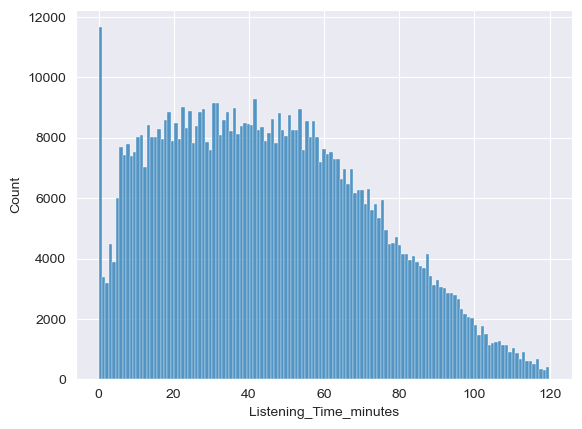

In [10]:
sns.histplot(plot_data, x="Listening_Time_minutes")

<a name="numerical"></a>
### 2.2. Numerical Features

In [11]:
# sns.pairplot(plot_data[numCols + ["Episode_No"]])

<a name="categorical"></a>
### 2.3 Categorical Features

In [12]:
def print_category_analysis(col_name: pd.Series):
    print(train_data[col_name].value_counts().to_string())
    print(set(test_data[col_name]) & set(train_data[col_name]))

In [13]:
print_category_analysis("Genre")

Genre
Sports        87606
Technology    86256
True Crime    85059
Lifestyle     82461
Comedy        81453
Business      80521
Health        71416
News          63385
Music         62743
Education     49100
{'Music', 'Comedy', 'Sports', 'Business', 'News', 'Lifestyle', 'Technology', 'Health', 'True Crime', 'Education'}


In [14]:
print_category_analysis("Publication_Day")

Publication_Day
Sunday       115946
Monday       111963
Friday       108237
Wednesday    107886
Thursday     104360
Saturday     103505
Tuesday       98103
{'Sunday', 'Friday', 'Tuesday', 'Wednesday', 'Saturday', 'Thursday', 'Monday'}


In [15]:
print_category_analysis("Publication_Time")

Publication_Time
Night        196849
Evening      195778
Afternoon    179460
Morning      177913
{'Morning', 'Afternoon', 'Evening', 'Night'}


In [16]:
print_category_analysis("Episode_Sentiment")

Episode_Sentiment
Neutral     251291
Negative    250116
Positive    248593
{'Negative', 'Positive', 'Neutral'}


<a name="missing"></a>
### 2.4. Missing Values

Most machine learning algorithms give an error when we train them on data with missing values. Therefore, it's important to identify them before deciding how to handle them (drop features or impute missing value).

In [17]:
missing_data = train_data.isnull().sum()
missing_data_per = missing_data / len(train_data) * 100
missing_data_per

id                              0.000000
Podcast_Name                    0.000000
Episode_Title                   0.000000
Episode_Length_minutes         11.612400
Genre                           0.000000
Host_Popularity_percentage      0.000000
Publication_Day                 0.000000
Publication_Time                0.000000
Guest_Popularity_percentage    19.470667
Number_of_Ads                   0.000133
Episode_Sentiment               0.000000
Listening_Time_minutes          0.000000
dtype: float64

<Axes: xlabel='None', ylabel='None'>

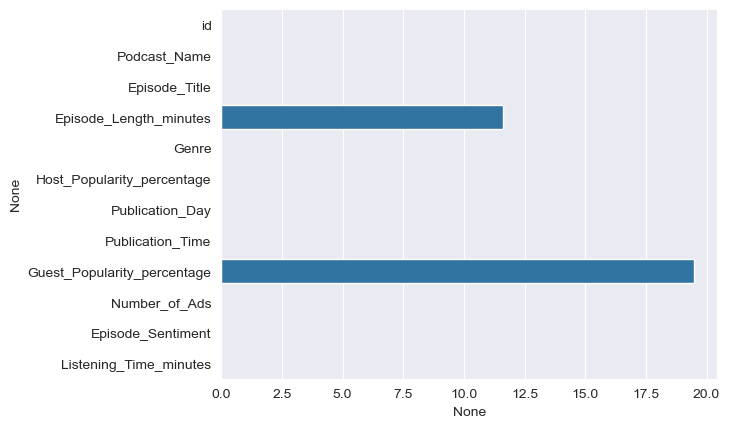

In [18]:
sns.barplot(y=missing_data_per.index,
            x=missing_data_per)

<Axes: title={'center': 'Episode_Length_minutes'}, xlabel='Genre'>

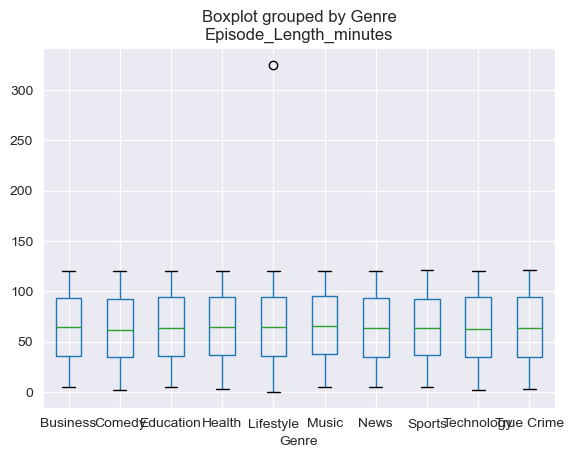

In [19]:
plot_data.boxplot(by ="Genre", column =["Episode_Length_minutes"])

<Axes: title={'center': 'Guest_Popularity_percentage'}, xlabel='Genre'>

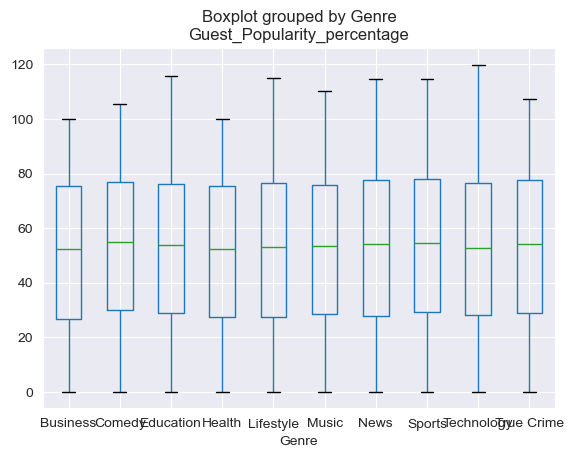

In [20]:
plot_data.boxplot(by ="Genre", column =["Guest_Popularity_percentage"])

array([<Axes: title={'center': 'Episode_Length_minutes'}, xlabel='Episode_Sentiment'>,
       <Axes: title={'center': 'Guest_Popularity_percentage'}, xlabel='Episode_Sentiment'>],
      dtype=object)

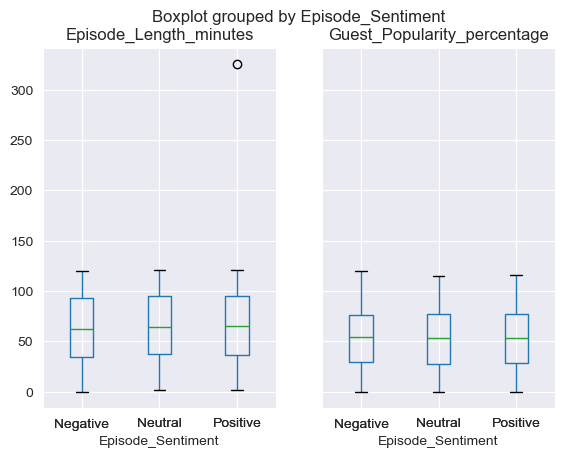

In [21]:
plot_data.boxplot(by ="Episode_Sentiment", column =["Episode_Length_minutes", "Guest_Popularity_percentage"])

<Axes: xlabel='Host_Popularity_percentage', ylabel='Episode_Length_minutes'>

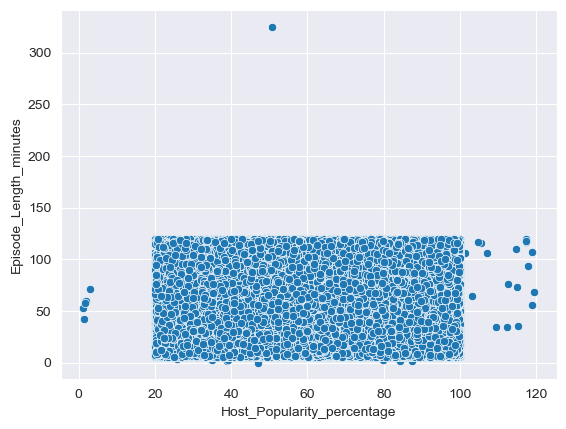

In [22]:
sns.scatterplot(data=plot_data, x="Host_Popularity_percentage", y="Episode_Length_minutes")

<Axes: xlabel='Host_Popularity_percentage', ylabel='Guest_Popularity_percentage'>

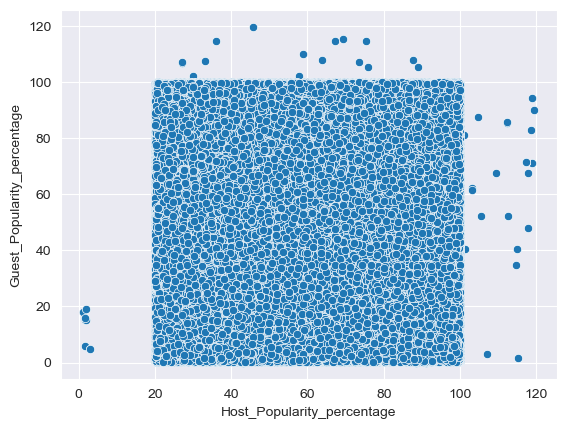

In [23]:
sns.scatterplot(data=plot_data, x="Host_Popularity_percentage", y="Guest_Popularity_percentage")

In [24]:
# There is no direct relation of any parameters with Episode_Length_Minute, Guest_Popularity_percentage and Number_of_Ads.

<a name="data-preprocessing"></a>
## 3. Data Preprocessing and Feature Engineering

<a name="unused-cat"></a>
## 3.1. Update Categorical Values

In [25]:
# Update train data to contain values from test data
for col in catCols:
    vals = test_data[col].unique()
    vals_train = train_data[col].unique()
    print(f"{col}: Different values {set(vals) - set(vals_train)}")

Podcast_Name: Different values set()
Episode_Title: Different values set()
Genre: Different values set()
Publication_Day: Different values set()
Publication_Time: Different values set()
Episode_Sentiment: Different values set()


<a name="missing-data"></a>
## 3.2. Missing Data Handling

In [26]:
from sklearn.impute import SimpleImputer

<a name="feature-encoding"></a>
## 3.3. Feature Encoder

In [27]:
from sklearn.preprocessing import OneHotEncoder

<a name="feature-drop"></a>
## 3.4. Feature Dropper

In [28]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureDropper(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, data):

        print("drop")
        
        return data.drop(["Podcast_Name", "Episode_Title"], axis=1, errors="ignore")

<a name="feature-add"></a>
## 3.5. Feature Adder

In [29]:
class FeatureAdder(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, data):

        print("Add")
        
        data["Episode_No"] = plot_data["Episode_Title"].str.split("Episode", expand=True)[1].astype(int)
        
        return data

<a name="pipeline"></a>
## 3.6. Pre-processing pipeline

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = Pipeline(
    steps=[
        ("feature_add", FeatureAdder()),
        ("feature_drop", FeatureDropper()),
    ("column_transform", 
         ColumnTransformer(
            transformers=[
                ("numerical_imputer", SimpleImputer(strategy="median"), ["Episode_No", "Episode_Length_minutes", "Guest_Popularity_percentage", "Number_of_Ads"]),
                ("onehot_encoder", OneHotEncoder(handle_unknown="ignore"), ["Genre", "Publication_Day", "Publication_Time", "Episode_Sentiment"])
            ])
)])

<a name="modeling"></a>
# 4. Modeling

<a name="data-split"></a>
## 4.1. Train and Test data split

In [31]:
# Split the data into training and test sets
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=22)

target = "Listening_Time_minutes"

for train_indices, test_indices in split.split(train_data, train_data[target]):
    train = train_data.loc[train_indices]
    test = train_data.loc[test_indices]

y_train = train[target]
y_test = test[target]
X_train = train.drop(columns=target)
X_test = test.drop(columns=target)

<a name="random-forest"></a>
## 4.2. Random Forest

In [32]:
# Create a pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([("preprocessor", preprocessor),
                        ("randomforest", RandomForestRegressor(warm_start=True, n_jobs=-1, random_state=22, verbose=2))])

In [33]:
rf_param_grid = [{"randomforest__n_estimators": [50, 100, 200],
                  "randomforest__max_depth": [20, 30]}]

#### Best public score in kaggle with Random Forest is 0.98437. Let's try another ensembling methods for classification and analyze their scores.

<a name="adaboost"></a>
## 4.3. AdaBoost

In [34]:
# Create a pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Define the base model
base_estimator = DecisionTreeClassifier()

ab_pipeline = Pipeline([("preprocessor", preprocessor),
                        ("adaboost", AdaBoostClassifier(estimator=base_estimator, random_state=22))])

In [35]:
# ab_param_grid = [{"adaboost__n_estimators": [300, 400, 500],
#                   "adaboost__learning_rate": [0.01, 0.1, 1, 10],
#                   "adaboost__estimator__max_depth": [1, 2, 3, 4]}]
ab_param_grid = [{"adaboost__n_estimators": [300]}]

### Select the pipeline and parameters for selected model

In [36]:
# Random Forest
pipeline = rf_pipeline
param_grid = rf_param_grid

# AdaBoost
# pipeline = ab_pipeline
# param_grid = ab_param_grid

In [37]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring="neg_root_mean_squared_error", return_train_score=True, n_jobs=-1, verbose=2)

In [38]:
def train_and_test_model(search_model, X_train, Y_train, X_test):

    search_model.fit(X_train, Y_train)
    
    # Create a variable for the best model
    best_model = search_model.best_estimator_
    print(best_model)

    x_test_final = best_model.transform(X_test)
    
    y_pred = best_model.predict(x_test_final)

    return best_model, y_pred

### Uncomment and run following code to identify best model hyperparemeters

In [39]:
from sklearn.metrics import root_mean_squared_error

best_model, y_pred = train_and_test_model(grid_search, X_train, y_train, X_test)

accuracy = root_mean_squared_error(y_test, y_pred)
print(accuracy)
best_model

Fitting 3 folds for each of 6 candidates, totalling 18 fits


KeyboardInterrupt: 

In [ ]:
_, predictions = train_and_test_model(grid_search, train_data.drop(columns=["id", target]), train_data[target], test_data.drop(columns="id"))

In [ ]:
submission_df = pd.DataFrame(test_data["id"])
submission_df[target] = predictions
submission_df.to_csv("data/randomforest_20250420.csv", index=False)